In [1]:
# ============================================================
# Setup
# ============================================================
import sys, os
_d = os.path.abspath(os.getcwd())
for _ in range(5):
    if os.path.isfile(os.path.join(_d, 'config.py')):
        break
    _d = os.path.dirname(_d)
sys.path.insert(0, os.path.join(_d, 'src'))
sys.path.insert(0, _d)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
from scipy import stats
from config import SUBJECTS, cv_result_csv, FIGURES_DIR

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

STAGES   = ['4.6', '4.7', '4.8']
STAGE_X  = [0, 1, 2]   # integer x-positions; labels set separately
STAGE_LABELS = ['4.6', '4.7', '4.8']
print('Setup complete. Figures will be saved to:', FIGURES_DIR)

Setup complete. Figures will be saved to: /gpfs/radev/project/kuan/my483/RL_twostep/organized/figures


In [2]:
# ============================================================
# Colour map & model registry
# ============================================================
COLOUR_MAP = {
    'MF':                   '#E41E27',
    'Hybrid':               '#FACC59',
    'MB':                   '#0F5BA7',
    'RAC+P':                '#31B5E9',
    'Asymmetric Inference':          '#6F3996',
    'LS':                   '#d6bccf'
}

# model CSV key  ->  (display label, colour key)
MODEL_META = {
    'hyb':           ('Hybrid',          'Hybrid'),
    'hyb_p':         ('Hybrid+P',        'Hybrid'),
    'hyb_pmulti':    ('Hybrid+Pmulti',   'Hybrid'),
    'hyb_inf':       ('Hybrid+Inf',      'Hybrid'),
    'mb':            ('MB',              'MB'),
    'mb_p':          ('MB+P',            'MB'),
    'mb_pmulti':     ('MB+Pmulti',       'MB'),
    'mf_p':          ('MF+P',            'MF'),
    'mf_pmulti':     ('MF+Pmulti',       'MF'),
    'ls_asym':       ('Asymmetric Inference',       'Asymmetric Inference'),      
    'ls_asym_p':     ('Inference+P',     'Asymmetric Inference'),
    'ls_asym_pmulti':('Inference+Pmulti','Asymmetric Inference'),
    'ls':           ('LS',              'LS'),
    'ls_p':         ('LS+P',            'LS'),
    'rac_p':         ('RAC+P',           'RAC+P'),
}

def clr(model_key):
    """Return hex colour for a model key."""
    ck = MODEL_META[model_key][1]
    return COLOUR_MAP.get(ck, '#888888')

def lbl(model_key):
    """Return display label for a model key."""
    return MODEL_META[model_key][0]

In [3]:
# ============================================================
# Load all CV CSV files
# ============================================================
ALL_MODELS = list(MODEL_META.keys())

dfs = {}
for model in ALL_MODELS:
    for stage in STAGES:
        path = cv_result_csv(model, stage)
        if os.path.exists(path):
            dfs[(model, stage)] = pd.read_csv(path)

# Quick overview
print(f'Loaded {len(dfs)} data files.')
for model in ALL_MODELS:
    loaded = [s for s in STAGES if (model, s) in dfs]
    missing = [s for s in STAGES if (model, s) not in dfs]
    tag = '  MISSING:' + str(missing) if missing else ''
    print(f'  {model:<20}  stages={loaded}{tag}')

Loaded 45 data files.
  hyb                   stages=['4.6', '4.7', '4.8']
  hyb_p                 stages=['4.6', '4.7', '4.8']
  hyb_pmulti            stages=['4.6', '4.7', '4.8']
  hyb_inf               stages=['4.6', '4.7', '4.8']
  mb                    stages=['4.6', '4.7', '4.8']
  mb_p                  stages=['4.6', '4.7', '4.8']
  mb_pmulti             stages=['4.6', '4.7', '4.8']
  mf_p                  stages=['4.6', '4.7', '4.8']
  mf_pmulti             stages=['4.6', '4.7', '4.8']
  ls_asym               stages=['4.6', '4.7', '4.8']
  ls_asym_p             stages=['4.6', '4.7', '4.8']
  ls_asym_pmulti        stages=['4.6', '4.7', '4.8']
  ls                    stages=['4.6', '4.7', '4.8']
  ls_p                  stages=['4.6', '4.7', '4.8']
  rac_p                 stages=['4.6', '4.7', '4.8']


## Fig A — Cross Validation vs Training Stage
Mean CV for five models across stages.
Solid lines: Hybrid+P, MB+P, MF+P.  Dashed lines: Inference+P (ls_asym_p), RAC+P.

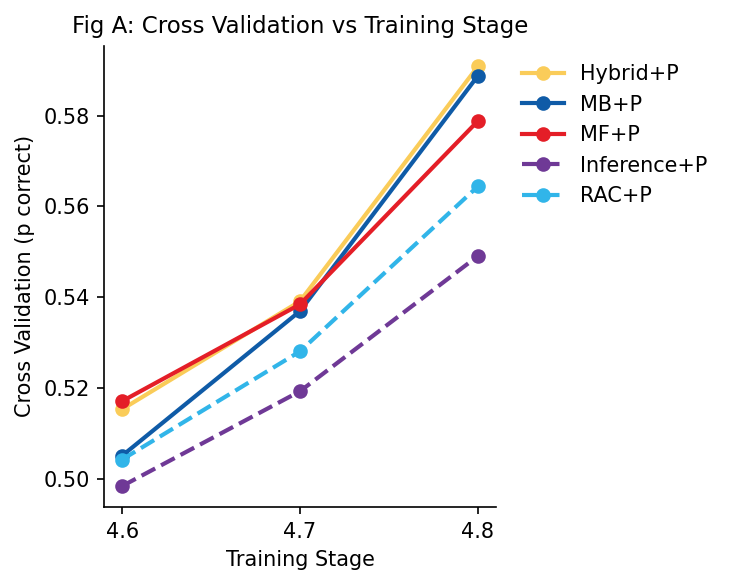

Saved FigA


In [4]:
# ============================================================
# Fig A — mean CV line plot
# ============================================================
FIGA_MODELS = [
    ('hyb_p',      '-'),
    ('mb_p',       '-'),
    ('mf_p',       '-'),
    ('ls_asym_p',  '--'),
    ('rac_p',      '--'),
]

fig, ax = plt.subplots(figsize=(5, 4))

for model_key, ls in FIGA_MODELS:
    means = [dfs[(model_key, s)]['Cross validation'].mean()
             if (model_key, s) in dfs else np.nan for s in STAGES]
    ax.plot(STAGE_X, means,
            linestyle=ls, marker='o', markersize=6, linewidth=2,
            color=clr(model_key), label=lbl(model_key))

ax.set_xticks(STAGE_X)
ax.set_xticklabels(STAGE_LABELS)
ax.set_xlabel('Training Stage')
ax.set_ylabel('Cross Validation (p correct)')
ax.set_title('Fig A: Cross Validation vs Training Stage')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'FigA_CV_vs_stage.png'), bbox_inches='tight')
plt.show()
print('Saved FigA')

## Fig B — Cross Validation Subject Variability
Grouped boxplot: 3 stage groups × 6 models.
T-tests (paired) comparing each model to Hybrid+P are reported below the figure.

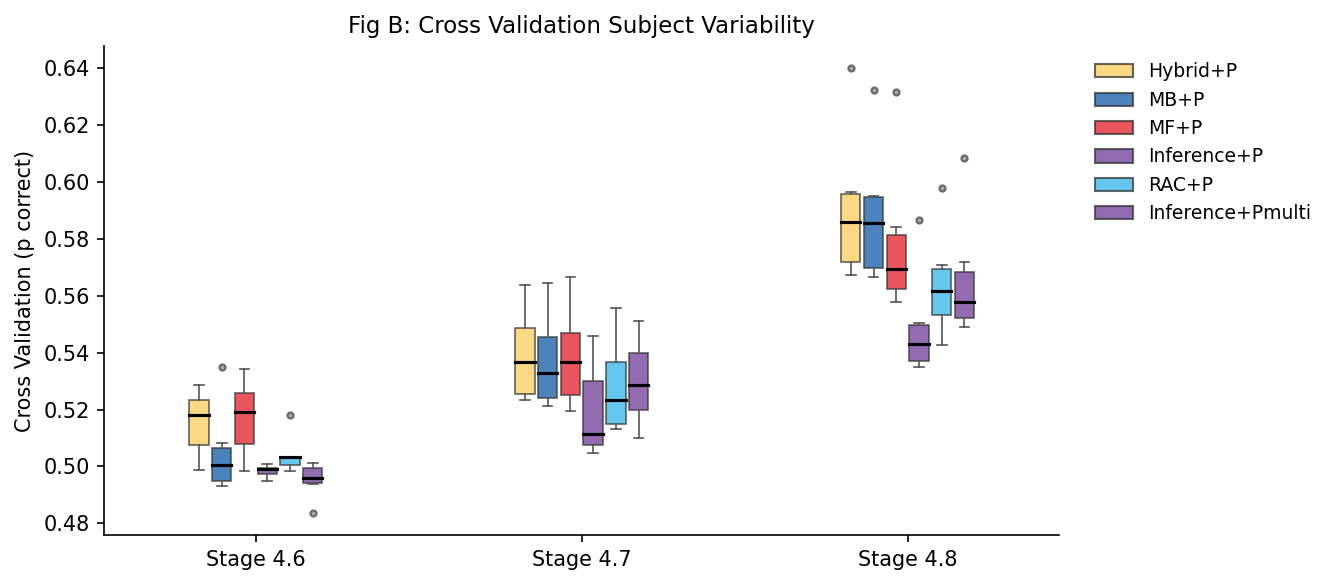

Saved FigB

=== Fig B: Paired t-test (each model vs Hybrid+P) ===
Model                              Stage 4.6             Stage 4.7             Stage 4.8
----------------------------------------------------------------------------------------
MB+P                    t=+1.58 p=0.175 ns       t=+1.56 p=0.178 ns       t=+1.75 p=0.140 ns     
MF+P                    t=-0.85 p=0.433 ns       t=+0.66 p=0.540 ns       t=+6.24 p=0.002 **     
Inference+P             t=+3.93 p=0.011 *        t=+6.84 p=0.001 **       t=+11.25 p=0.000 ***    
RAC+P                   t=+2.76 p=0.040 *        t=+9.41 p=0.000 ***      t=+7.12 p=0.001 ***    
Inference+Pmulti        t=+5.47 p=0.003 **       t=+6.32 p=0.001 **       t=+8.40 p=0.000 ***    


In [5]:
# ============================================================
# Fig B — grouped boxplot (6 models × 3 stages)
# ============================================================
# 6 models:
#   hyb_p (1), mb_p (2), mf_p (3),
#   ls_asym_p = 'Inference+P' (4), rac_p (5),
#   ls_asym_pmulti = 'Inference+Pmulti' (6)
FIGB_MODELS = [
    'hyb_p', 'mb_p', 'mf_p', 'ls_asym_p', 'rac_p', 'ls_asym_pmulti',
]

n_m = len(FIGB_MODELS)
group_gap   = 1.0          # distance between stage groups
box_width   = 0.12
group_width = n_m * box_width

fig, ax = plt.subplots(figsize=(9, 4))

for si, stage in enumerate(STAGES):
    gc = si * (group_width + group_gap)  # group centre
    for mi, model_key in enumerate(FIGB_MODELS):
        if (model_key, stage) not in dfs:
            continue
        xpos = gc + (mi - n_m / 2 + 0.5) * box_width
        data = dfs[(model_key, stage)]['Cross validation'].values
        bp = ax.boxplot(
            data,
            positions=[xpos],
            widths=box_width * 0.85,
            patch_artist=True,
            medianprops=dict(color='black', linewidth=1.5),
            whiskerprops=dict(color='#555555', linewidth=0.8),
            capprops=dict(color='#555555', linewidth=0.8),
            flierprops=dict(marker='o', markerfacecolor='#555555',
                            markersize=3, linestyle='none', alpha=0.5),
            boxprops=dict(facecolor=clr(model_key), alpha=0.75,
                          edgecolor='#333333', linewidth=0.8),
        )

# x-ticks at group centres
group_centres = [si * (group_width + group_gap) for si in range(len(STAGES))]
ax.set_xticks(group_centres)
ax.set_xticklabels(['Stage 4.6', 'Stage 4.7', 'Stage 4.8'])
ax.set_ylabel('Cross Validation (p correct)')
ax.set_title('Fig B: Cross Validation Subject Variability')

handles = [mpatches.Patch(facecolor=clr(m), label=lbl(m), alpha=0.75,
                          edgecolor='#333333')
           for m in FIGB_MODELS]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left',
          frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'FigB_CV_variability.png'), bbox_inches='tight')
plt.show()
print('Saved FigB')

# ── Paired t-tests vs Hybrid+P ──────────────────────────────────────────────
print('\n=== Fig B: Paired t-test (each model vs Hybrid+P) ===')
hdr = f"{'Model':<22}" + ''.join(f"{'Stage '+s:>22}" for s in STAGES)
print(hdr)
print('-' * (22 + 22 * len(STAGES)))
for model_key in FIGB_MODELS[1:]:   # skip hyb_p itself
    row = f"{lbl(model_key):<22}"
    for stage in STAGES:
        if (model_key, stage) in dfs and ('hyb_p', stage) in dfs:
            a = dfs[('hyb_p',    stage)]['Cross validation'].values
            b = dfs[(model_key,  stage)]['Cross validation'].values
            t, p = stats.ttest_rel(a, b)
            sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
            row += f"  t={t:+.2f} p={p:.3f} {sig:3s}    "
        else:
            row += f"{'N/A':>22}"
    print(row)

## Fig C — Hybrid+P Parameters: Wmf and Wmb
Each subject shown as thin transparent line; mean ± SEM as thick line + shaded band.

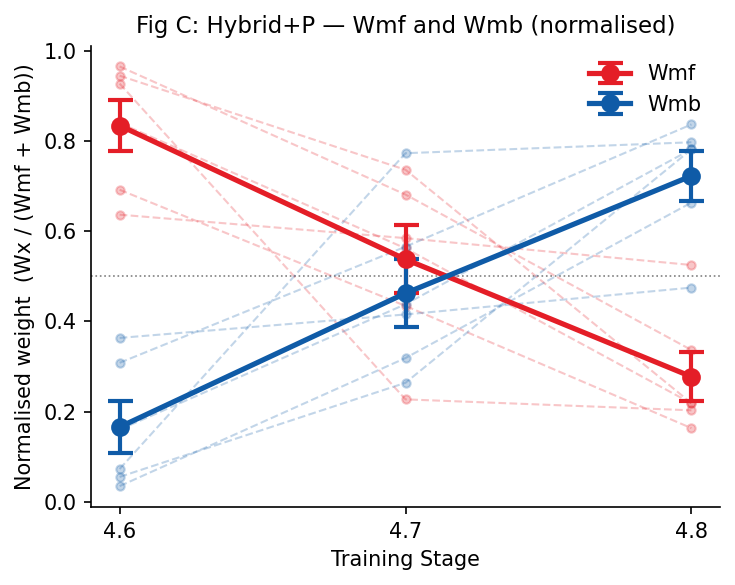

Saved FigC


In [6]:
# ============================================================
# Fig C — Hybrid+P Parameters: Wmf and Wmb (normalised so Wmf+Wmb=1)
# ============================================================
PARAM_COLORS = {'Wmf': '#E41E27', 'Wmb': '#0F5BA7'}

# Build per-subject normalised values: Wmf_norm = Wmf / (Wmf + Wmb)
# subj_norm[param][subj][stage_idx] = normalised value
subj_norm = {p: {} for p in PARAM_COLORS}

for stage_idx, stage in enumerate(STAGES):
    if ('hyb_p', stage) not in dfs:
        continue
    d = dfs[('hyb_p', stage)].set_index('Subject')
    for subj in SUBJECTS:
        if subj not in d.index:
            continue
        if 'Wmf' not in d.columns or 'Wmb' not in d.columns:
            continue
        wmf = d.loc[subj, 'Wmf']
        wmb = d.loc[subj, 'Wmb']
        total = wmf + wmb
        if total == 0:
            continue
        subj_norm['Wmf'].setdefault(subj, {})[stage_idx] = wmf / total
        subj_norm['Wmb'].setdefault(subj, {})[stage_idx] = wmb / total

fig, ax = plt.subplots(figsize=(5, 4))

for param, color in PARAM_COLORS.items():
    # thin dashed subject lines
    for sv in subj_norm[param].values():
        xs = sorted(sv.keys())
        ys = [sv[x] for x in xs]
        ax.plot(xs, ys, color=color, alpha=0.25,
                linewidth=1.0, linestyle='--', marker='o',
                markersize=4, zorder=1)

    # mean ± SEM across subjects at each stage
    means, sems, valid_x = [], [], []
    for stage_idx in STAGE_X:
        vals = [sv[stage_idx] for sv in subj_norm[param].values()
                if stage_idx in sv]
        if vals:
            v = np.array(vals)
            means.append(v.mean())
            sems.append(v.std(ddof=1) / np.sqrt(len(v)))
            valid_x.append(stage_idx)

    ax.errorbar(valid_x, means, yerr=sems,
                color=color, linewidth=2.5, marker='o', markersize=8,
                capsize=6, capthick=2.0, elinewidth=2.0,
                label=param, zorder=2)

ax.axhline(0.5, color='grey', linewidth=0.8, linestyle=':', zorder=0)
ax.set_xticks(STAGE_X)
ax.set_xticklabels(STAGE_LABELS)
ax.set_xlabel('Training Stage')
ax.set_ylabel('Normalised weight  (Wx / (Wmf + Wmb))')
ax.set_title('Fig C: Hybrid+P — Wmf and Wmb (normalised)')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'FigC_hyb_p_params.png'), bbox_inches='tight')
plt.show()
print('Saved FigC')

## Fig C2 — Hybrid+Inf Parameters: Wmf and Winf (normalised)
Same style as Fig C but for the `hyb_inf` model.
Normalised so that Wmf + Winf = 1.

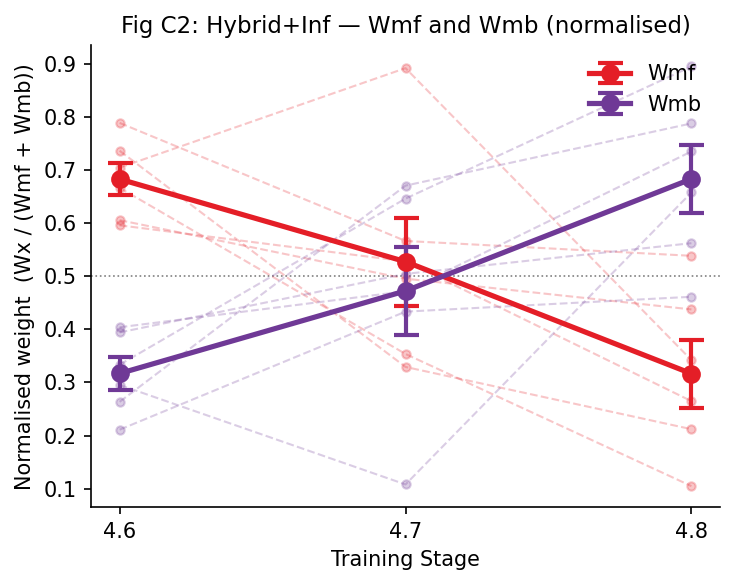

Saved FigC2


In [7]:
# ============================================================
# Fig C2 — Hybrid+Inf Parameters: Wmf and Wmb (normalised so Wmf+Wmb=1)
# ============================================================
PARAM_COLORS_INF = {'Wmf': '#E41E27', 'Wmb': '#6F3996'}

# Build per-subject normalised values
subj_norm_inf = {p: {} for p in PARAM_COLORS_INF}

for stage_idx, stage in enumerate(STAGES):
    if ('hyb_inf', stage) not in dfs:
        continue
    d = dfs[('hyb_inf', stage)].set_index('Subject')
    for subj in SUBJECTS:
        if subj not in d.index:
            continue
        if 'Wmf' not in d.columns or 'Wmb' not in d.columns:
            continue
        wmf = d.loc[subj, 'Wmf']
        wmb = d.loc[subj, 'Wmb']
        total = wmf + wmb
        if total == 0:
            continue
        subj_norm_inf['Wmf'].setdefault(subj, {})[stage_idx] = wmf / total
        subj_norm_inf['Wmb'].setdefault(subj, {})[stage_idx] = wmb / total

fig, ax = plt.subplots(figsize=(5, 4))

for param, color in PARAM_COLORS_INF.items():
    # thin dashed subject lines
    for sv in subj_norm_inf[param].values():
        xs = sorted(sv.keys())
        ys = [sv[x] for x in xs]
        ax.plot(xs, ys, color=color, alpha=0.25,
                linewidth=1.0, linestyle='--', marker='o',
                markersize=4, zorder=1)

    # mean ± SEM
    means, sems, valid_x = [], [], []
    for stage_idx in STAGE_X:
        vals = [sv[stage_idx] for sv in subj_norm_inf[param].values()
                if stage_idx in sv]
        if vals:
            v = np.array(vals)
            means.append(v.mean())
            sems.append(v.std(ddof=1) / np.sqrt(len(v)))
            valid_x.append(stage_idx)

    ax.errorbar(valid_x, means, yerr=sems,
                color=color, linewidth=2.5, marker='o', markersize=8,
                capsize=6, capthick=2.0, elinewidth=2.0,
                label=param, zorder=2)

ax.axhline(0.5, color='grey', linewidth=0.8, linestyle=':', zorder=0)
ax.set_xticks(STAGE_X)
ax.set_xticklabels(STAGE_LABELS)
ax.set_xlabel('Training Stage')
ax.set_ylabel('Normalised weight  (Wx / (Wmf + Wmb))')
ax.set_title('Fig C2: Hybrid+Inf — Wmf and Wmb (normalised)')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'FigC2_hyb_inf_params.png'), bbox_inches='tight')
plt.show()
print('Saved FigC2')

## Fig D — P vs P-multi Comparison
Left three panels: per-model-family comparison of +P (solid) vs +Pmulti (dashed).
Right panel: summary with all 6 lines together.

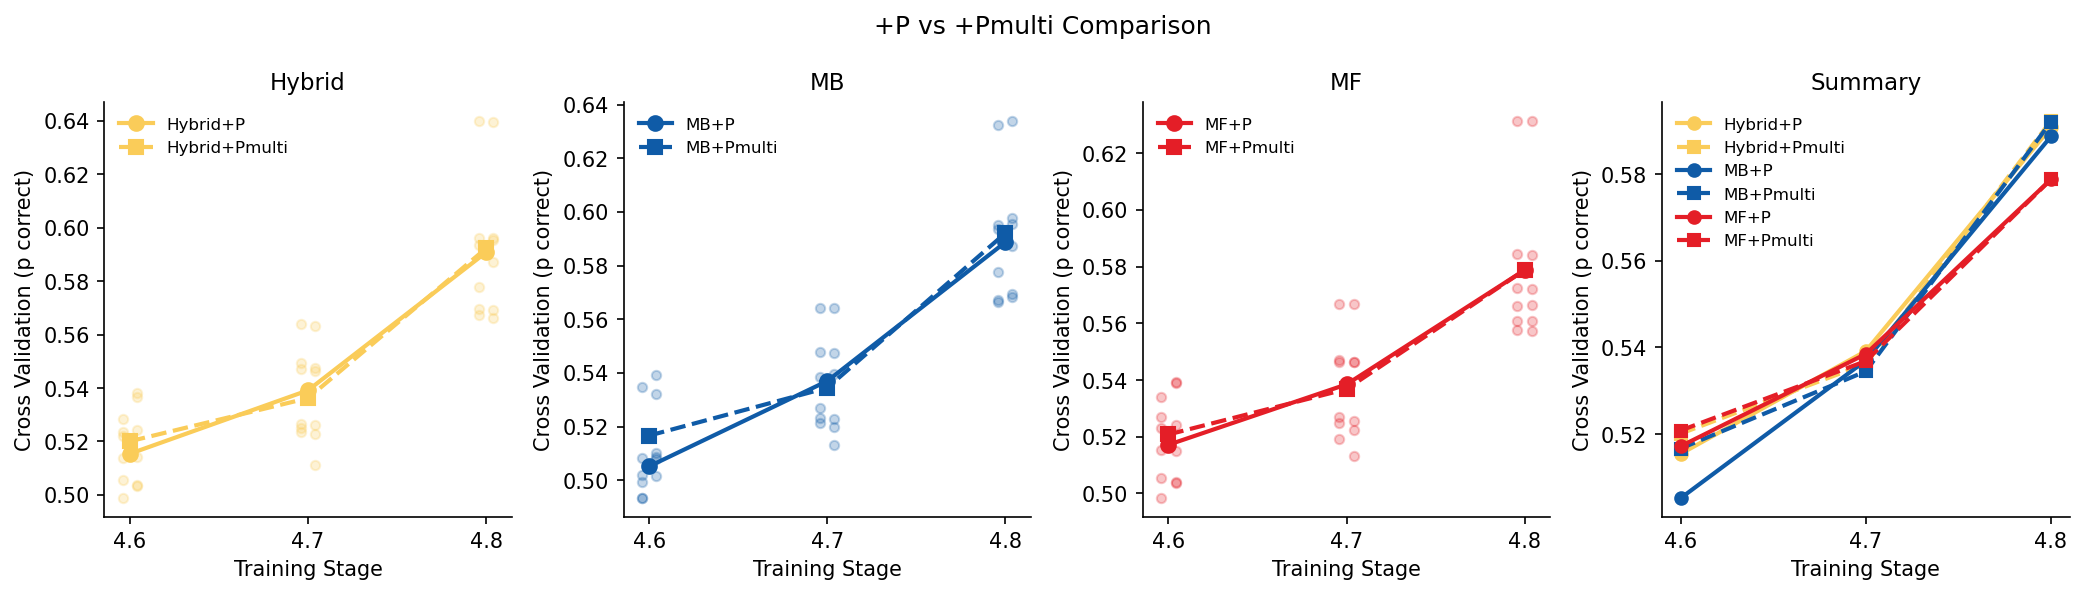

Saved FigD


In [8]:
# ============================================================
# Fig D — P vs Pmulti (line plots + summary)
# ============================================================
FIGD_PAIRS = [
    ('hyb_p', 'hyb_pmulti', 'Hybrid'),
    ('mb_p',  'mb_pmulti',  'MB'),
    ('mf_p',  'mf_pmulti',  'MF'),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=False)

# ── Individual pair panels ────────────────────────────────────────────────
for i, (pk, pmk, name) in enumerate(FIGD_PAIRS):
    ax = axes[i]
    color = clr(pk)

    p_means  = [dfs[(pk,  s)]['Cross validation'].mean()
                if (pk,  s) in dfs else np.nan for s in STAGES]
    pm_means = [dfs[(pmk, s)]['Cross validation'].mean()
                if (pmk, s) in dfs else np.nan for s in STAGES]

    # individual subjects (thin)
    for stage_idx, stage in enumerate(STAGES):
        for key, offset, marker in [(pk, -0.04, 'o'), (pmk, 0.04, 's')]:
            if (key, stage) in dfs:
                vals = dfs[(key, stage)]['Cross validation'].values
                xs = [stage_idx + offset] * len(vals)
                ax.scatter(xs, vals, color=color, alpha=0.25,
                           s=20, zorder=1)

    ax.plot(STAGE_X, p_means,  color=color, linestyle='-',
            marker='o', linewidth=2, markersize=7, label=f'{name}+P',    zorder=2)
    ax.plot(STAGE_X, pm_means, color=color, linestyle='--',
            marker='s', linewidth=2, markersize=7, label=f'{name}+Pmulti', zorder=2)

    ax.set_xticks(STAGE_X)
    ax.set_xticklabels(STAGES)
    ax.set_xlabel('Training Stage')
    ax.set_ylabel('Cross Validation (p correct)')
    ax.set_title(name)
    ax.legend(fontsize=8, frameon=False)

# ── Summary panel (all 6 lines) ───────────────────────────────────────────
ax = axes[3]
for pk, pmk, name in FIGD_PAIRS:
    color = clr(pk)
    p_means  = [dfs[(pk,  s)]['Cross validation'].mean()
                if (pk,  s) in dfs else np.nan for s in STAGES]
    pm_means = [dfs[(pmk, s)]['Cross validation'].mean()
                if (pmk, s) in dfs else np.nan for s in STAGES]
    ax.plot(STAGE_X, p_means,  color=color, linestyle='-',
            marker='o', linewidth=2, markersize=6, label=f'{name}+P')
    ax.plot(STAGE_X, pm_means, color=color, linestyle='--',
            marker='s', linewidth=2, markersize=6, label=f'{name}+Pmulti')

ax.set_xticks(STAGE_X)
ax.set_xticklabels(STAGES)
ax.set_xlabel('Training Stage')
ax.set_ylabel('Cross Validation (p correct)')
ax.set_title('Summary')
ax.legend(fontsize=8, frameon=False)

fig.suptitle('+P vs +Pmulti Comparison', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'FigD_P_vs_Pmulti.png'), bbox_inches='tight')
plt.show()
print('Saved FigD')

## Fig E — All Models Cross Validation (extension of Fig B)
All available models, grouped by training stage.

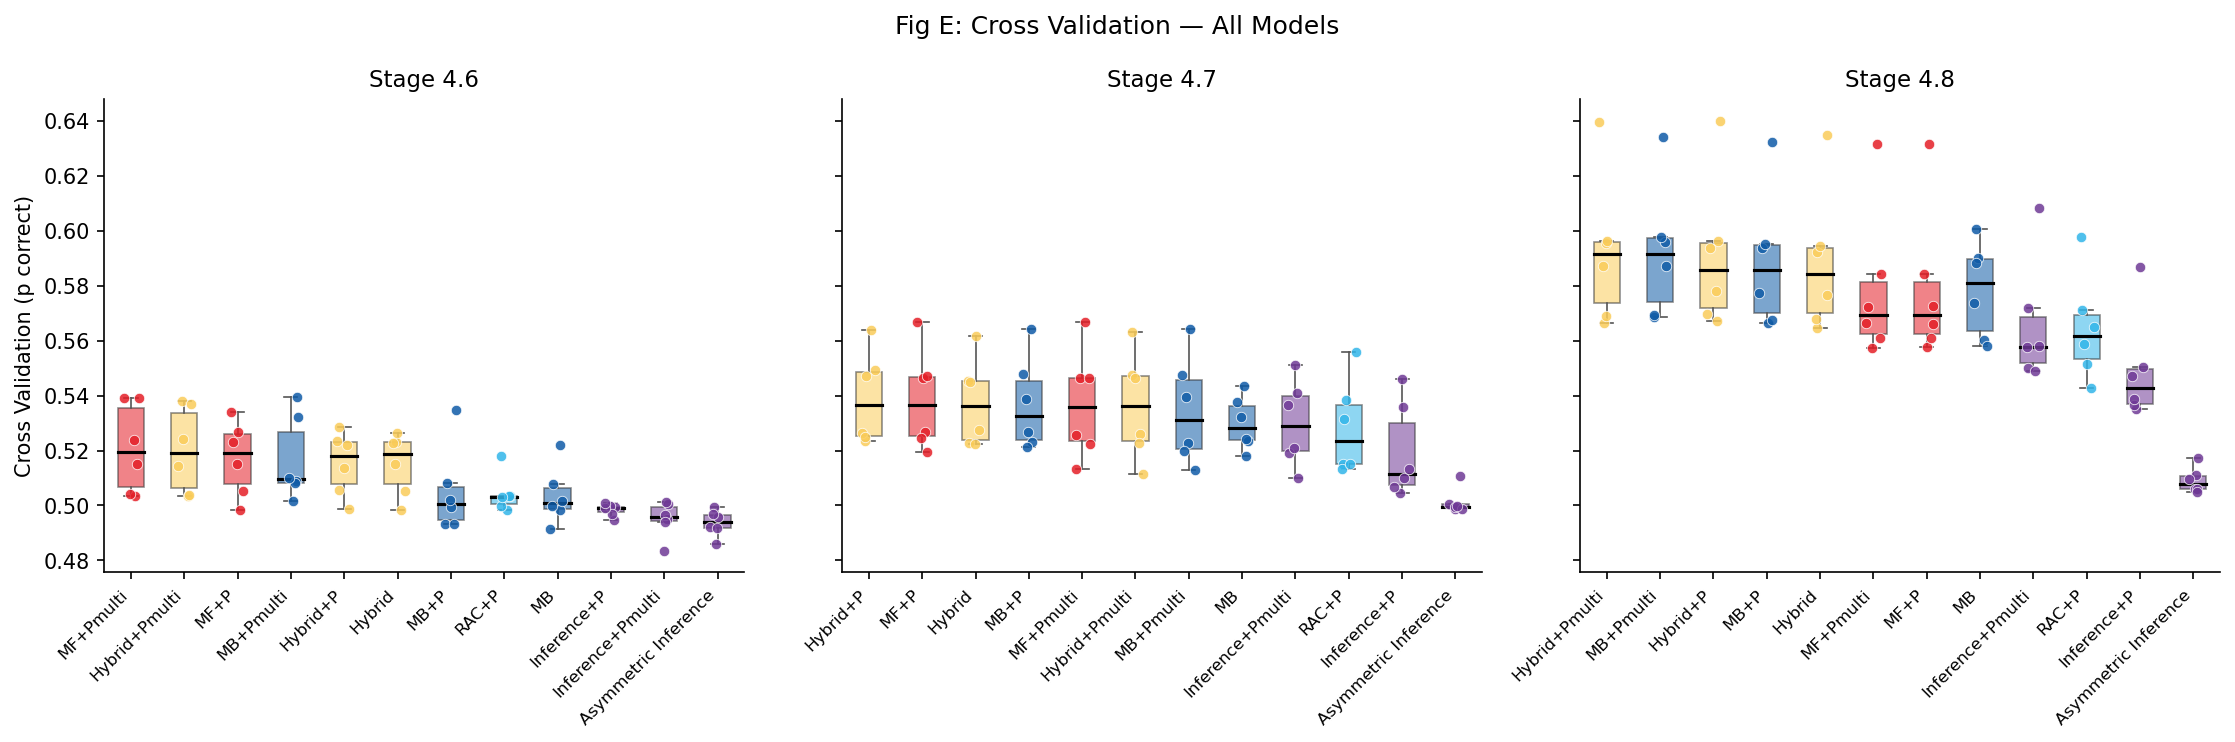

Saved FigE


In [9]:
# ============================================================
# Fig E — all models boxplot (one panel per stage, sorted by mean CV desc)
# ============================================================
FIGE_MODELS = [
    'hyb', 'hyb_p', 'hyb_pmulti',
    'mb',  'mb_p',  'mb_pmulti',
    'mf_p', 'mf_pmulti',
    'ls_asym', 'ls_asym_p', 'ls_asym_pmulti',
    'rac_p',
]
# Keep only models we actually have data for
FIGE_MODELS = [m for m in FIGE_MODELS
               if any((m, s) in dfs for s in STAGES)]

rng = np.random.default_rng(42)
box_width = 0.6

fig, axes = plt.subplots(1, len(STAGES), figsize=(5 * len(STAGES), 5), sharey=True)

for ax, stage, stage_label in zip(axes, STAGES, STAGE_LABELS):
    # Sort models by mean CV descending for this stage
    def mean_cv(m):
        if (m, stage) in dfs:
            return dfs[(m, stage)]['Cross validation'].mean()
        return -np.inf

    sorted_models = sorted(FIGE_MODELS, key=mean_cv, reverse=True)

    for mi, model_key in enumerate(sorted_models):
        if (model_key, stage) not in dfs:
            continue
        data = dfs[(model_key, stage)]['Cross validation'].values
        color = clr(model_key)

        ax.boxplot(
            data,
            positions=[mi],
            widths=box_width * 0.82,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color='black', linewidth=1.5),
            whiskerprops=dict(color='#555555', linewidth=0.8),
            capprops=dict(color='#555555', linewidth=0.8),
            boxprops=dict(facecolor=color, alpha=0.55,
                          edgecolor='#333333', linewidth=0.8),
        )

        jitter = rng.uniform(-box_width * 0.25, box_width * 0.25, size=len(data))
        ax.scatter(mi + jitter, data,
                   color=color, s=25, alpha=0.85, zorder=3,
                   edgecolors='white', linewidths=0.4)

    ax.set_xticks(range(len(sorted_models)))
    ax.set_xticklabels([lbl(m) for m in sorted_models],
                       rotation=45, ha='right', fontsize=8)
    ax.set_title(f'Stage {stage_label}')
    if ax is axes[0]:
        ax.set_ylabel('Cross Validation (p correct)')

fig.suptitle('Fig E: Cross Validation — All Models', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'FigE_all_models.png'), bbox_inches='tight')
plt.show()
print('Saved FigE')